In [1]:
#uncomment and run this if need be
#!pip install -r ../requirements.txt


In [2]:
# === Step 1: Imports + Paths ===
from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
SEED = 1337
random.seed(SEED)
np.random.seed(SEED)

BASE_DIR = Path(".").resolve()
ROOT_DIR = BASE_DIR.parent
DATA_DIR = ROOT_DIR / "csv"

HUMAN_SAFE_CSV = DATA_DIR / "scenario3_human_per_user_safe_44.csv"
#RNG_SAFE_CSV   = DATA_DIR / "scenario3_rng_per_user_safe_44.csv"
TARGETED_PER_USER_SAFE_CSV = DATA_DIR / "scenario3_targeted_per_user_safe_44.csv"
#TARGETED_FLAT_SAFE_CSV     = DATA_DIR / "scenario3_targeted_flatness_safe_44.csv"
TARGETED_SUCC_SAFE_CSV     = DATA_DIR / "scenario3_targeted_success_safe_44.csv"

HUMAN_FLATNESS_SAFE_CSV = DATA_DIR / "scenario3_human_flatness_safe_44.csv"

print("ROOT_DIR:", ROOT_DIR)
print("DATA_DIR:", DATA_DIR)

ROOT_DIR: D:\All\All\Lab\PII Research\Next Phase_of_Research_post_Candidacy\Attack\ccs\CCS\ccs_artifact_anonymous\scenario3
DATA_DIR: D:\All\All\Lab\PII Research\Next Phase_of_Research_post_Candidacy\Attack\ccs\CCS\ccs_artifact_anonymous\scenario3\csv


In [4]:
# === Step 2: Load data ===
required_files = [
    HUMAN_SAFE_CSV,
    TARGETED_PER_USER_SAFE_CSV,
    TARGETED_SUCC_SAFE_CSV,
]

for f in required_files:
    if not f.exists():
        raise FileNotFoundError(f"Missing file: {f}")

human_safe_df = pd.read_csv(HUMAN_SAFE_CSV)
targeted_per_user_safe_df = pd.read_csv(TARGETED_PER_USER_SAFE_CSV)
targeted_succ_safe_df = pd.read_csv(TARGETED_SUCC_SAFE_CSV)

print("Loaded all data successfully")
print("Human users:", human_safe_df["anon_user_id"].nunique())

Loaded all data successfully
Human users: 44


In [5]:
# === Step 3: Validate required columns ===
REQUIRED_COLS = {
    "anon_user_id", "model", "true_rank", "mrr",
    "hit_at_1", "hit_at_3", "hit_at_5", "hit_at_10", "hit_at_20"
}

missing_human = REQUIRED_COLS - set(human_safe_df.columns)

if missing_human:
    raise ValueError(f"Human safe CSV is missing columns: {sorted(missing_human)}")

print("✔ Required columns are present in human safe CSV.")

✔ Required columns are present in human safe CSV.


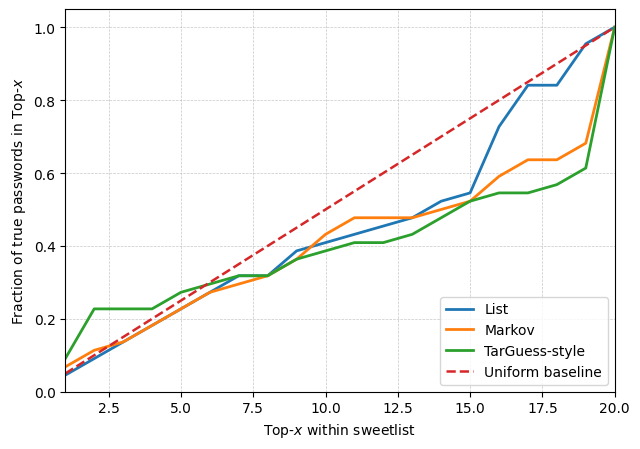

In [6]:
# === Human flatness ===

def compute_flatness(df):
    ks = np.arange(1, 21)
    flat = [(df["true_rank"] <= k).mean() for k in ks]
    return ks, flat

name_map = {
    "List (RockYou freq)": "List",
    "Markov backoff (n-gram)": "Markov",
    "PCFG-lite": "TarGuess-style",
}

plt.figure(figsize=(6.5, 4.6))

for model_name in human_safe_df["model"].unique():
    df_model = human_safe_df[human_safe_df["model"] == model_name]
    ks, flat = compute_flatness(df_model)

    short_name = name_map.get(model_name, model_name)
    plt.plot(ks, flat, linewidth=2.0, label=short_name)

# baseline
plt.plot(ks, ks / 20, linestyle="--", linewidth=1.8, label="Uniform baseline")

plt.xlabel("Top-$x$ within sweetlist")
plt.ylabel("Fraction of true passwords in Top-$x$")

plt.xlim(1, 20)
plt.ylim(0, 1.05)
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
plt.legend(loc="lower right")
plt.tight_layout()

plt.show()

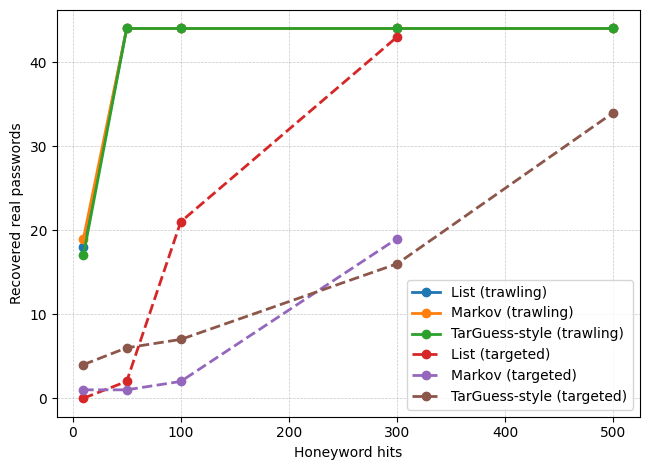

In [7]:
# === Scenario 3 success plot ===

FINAL_BETA = 1.0
SUCCESS_XS = [10, 50, 100, 300, 500]

def targeted_success_points(row, xs=SUCCESS_XS):
    ys = []
    for x in xs:
        v = row.get(f"success_at_{x}", np.nan)
        ys.append(np.nan if pd.isna(v) else float(v))
    return ys

def untargeted_recovery_points(df, xs=SUCCESS_XS):
    ys = []
    for x in xs:
        cutoff = min(x, 20)
        ys.append(float((df["true_rank"] <= cutoff).sum()))
    return ys

plt.figure(figsize=(6.6, 4.8))

name_map = {
    "List (RockYou freq)": "List",
    "Markov backoff (n-gram)": "Markov",
    "PCFG-lite": "TarGuess-style",
    "Targeted List": "List",
    "Targeted Markov": "Markov",
    "Targeted PCFG-lite": "TarGuess-style",
}

# trawling
for model_name in human_safe_df["model"].unique():
    sub = human_safe_df[human_safe_df["model"] == model_name].copy()
    ys = untargeted_recovery_points(sub, xs=SUCCESS_XS)
    short_name = name_map.get(model_name, model_name)
    plt.plot(
        SUCCESS_XS,
        ys,
        marker="o",
        linewidth=2.0,
        label=f"{short_name} (trawling)"
    )

# targeted
targeted_beta_df = targeted_succ_safe_df[
    targeted_succ_safe_df["beta"] == FINAL_BETA
].copy()

for _, row in targeted_beta_df.iterrows():
    short_name = name_map.get(row["model"], row["model"])
    ys = targeted_success_points(row, xs=SUCCESS_XS)
    plt.plot(
        SUCCESS_XS,
        ys,
        marker="o",
        linestyle="--",
        linewidth=2.0,
        label=f"{short_name} (targeted)"
    )

plt.xlabel("Honeyword hits")
plt.ylabel("Recovered real passwords")
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
plt.legend(loc="lower right", frameon=True, ncol=1)
plt.tight_layout()
plt.show()

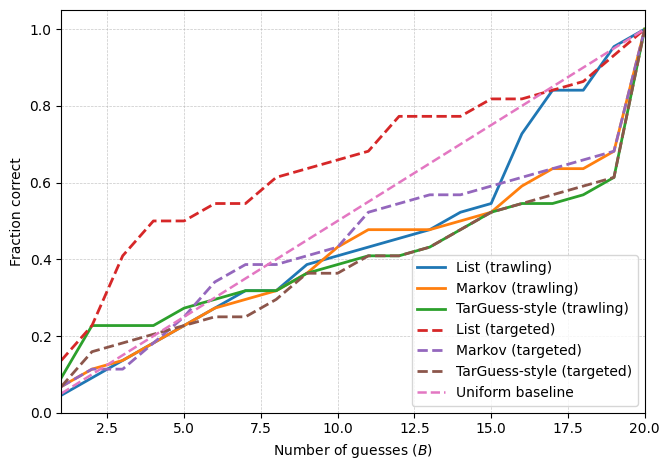

In [8]:
# === Scenario 3 PGC: trawling vs targeted ===

MAX_B = 20
FINAL_BETA = 1.0

def pgc_from_true_rank(df, max_b=20):
    budgets = np.arange(1, max_b + 1)
    pgc = [float((df["true_rank"] <= b).mean()) for b in budgets]
    return budgets, pgc

name_map = {
    "List (RockYou freq)": "List",
    "Markov backoff (n-gram)": "Markov",
    "PCFG-lite": "TarGuess-style",
    "Targeted List": "List",
    "Targeted Markov": "Markov",
    "Targeted PCFG-lite": "TarGuess-style",
}

plt.figure(figsize=(6.8, 4.8))

# trawling
for model_name in human_safe_df["model"].unique():
    sub = human_safe_df[human_safe_df["model"] == model_name].copy()
    budgets, pgc = pgc_from_true_rank(sub, max_b=MAX_B)
    short_name = name_map.get(model_name, model_name)
    plt.plot(
        budgets,
        pgc,
        linewidth=2.0,
        label=f"{short_name} (trawling)"
    )

# targeted
targeted_beta_df = targeted_per_user_safe_df[
    targeted_per_user_safe_df["beta"] == FINAL_BETA
].copy()

for model_name in targeted_beta_df["model"].unique():
    sub = targeted_beta_df[targeted_beta_df["model"] == model_name].copy()
    budgets, pgc = pgc_from_true_rank(sub, max_b=MAX_B)
    short_name = name_map.get(model_name, model_name)
    plt.plot(
        budgets,
        pgc,
        linestyle="--",
        linewidth=2.0,
        label=f"{short_name} (targeted)"
    )

# uniform baseline
plt.plot(
    range(1, MAX_B + 1),
    [b / MAX_B for b in range(1, MAX_B + 1)],
    linestyle="--",
    linewidth=1.8,
    label="Uniform baseline"
)

plt.xlabel("Number of guesses ($B$)")
plt.ylabel("Fraction correct")

plt.xlim(1, MAX_B)
plt.ylim(0, 1.05)
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
plt.legend(loc="lower right", frameon=True)
plt.tight_layout()
plt.show()

# 